In [ ]:
!pip install rdkit umap-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 44.1 MB/s eta 0:00:00


In [ ]:
# chargement de data

In [ ]:
import pandas as pd
from rdkit import Chem

df = pd.read_csv('generated_molecules.csv')
print(df.shape)
print(df.columns)
print(df.head())

(3000, 3)
Index(['smiles', 'score_QED', 'source_smiles'], dtype='object')
                                          smiles  score_QED  \
0                    O=C(Cc1cc[nH]n1)NCCc1ccccc1   0.811823   
1                    O=C(Cc1cc[nH]n1)NCCC(F)(F)F   0.797042   
2                    O=C(Cc1cc[nH]n1)NCCC(F)(F)F   0.797042   
3  Cc1cccn2c(=O)c(C(=O)N(C)[C@H](CN)CC(C)C)cnc12   0.905040   
4      Cc1cccn2c(=O)c(C(=O)N(CCN(C)C)C(C)C)cnc12   0.836863   

                                       source_smiles  
0                              O=C(Cc1cc[nH]n1)NCCCO  
1                              O=C(Cc1cc[nH]n1)NCCCO  
2                              O=C(Cc1cc[nH]n1)NCCCO  
3  Cc1cccn2c(=O)c(C(=O)N(C)[C@H](c3ccccc3)C(C)C)c...  
4  Cc1cccn2c(=O)c(C(=O)N(C)[C@H](c3ccccc3)C(C)C)c...  


In [ ]:
# Filtrage PAINS + SA Score

In [ ]:
from rdkit import Chem
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams
import urllib.request

# ── Télécharger les 2 fichiers nécessaires pour SA Score ──
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
    "sascorer.py"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
    "fpscores.pkl.gz"
)
import sascorer

# ── Filtre PAINS ──
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog.FilterCatalog(params)

def passes_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return not catalog.HasMatch(mol)

def get_sa_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sascorer.calculateScore(mol)

# ── Appliquer les filtres ──
df['valid']    = df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)
df['pains_ok'] = df['smiles'].apply(passes_pains)
df['SA_Score'] = df['smiles'].apply(get_sa_score)

# ── Filtrer ──
df_filtered = df[
    (df['valid'] == True) &
    (df['pains_ok'] == True) &
    (df['SA_Score'] < 4)
].copy()

df_filtered = df_filtered.sort_values('score_QED', ascending=False)
print(f"Avant filtrage : {len(df)}")
print(f"Après filtrage : {len(df_filtered)}")
print(df_filtered.head())

Avant filtrage : 3000
Après filtrage : 2874
                                       smiles  score_QED  \
1785            O=C(O)c1cnn(Cc2ccc(Br)cc2F)c1   0.947229   
2559  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070   
2560  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070   
2561  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070   
2952       NC1(c2ccnc(Cc3ccc(Cl)cc3)n2)CCOCC1   0.946784   

                                         source_smiles  valid  pains_ok  \
1785                          Cc1cnn(Cc2ccc(Br)cc2F)c1   True      True   
2559            O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@H](O)C1   True      True   
2560            O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@H](O)C1   True      True   
2561            O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@H](O)C1   True      True   
2952  COc1ccc(Cc2nccc(C3(c4ccccc4Cl)CC[NH2+]CC3)n2)cc1   True      True   

      SA_Score  
1785  2.116309  
2559  2.773772  
2560  2.773772  
2561  2.773772  
2952  2.685817  


In [ ]:
# Fingerprints + UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


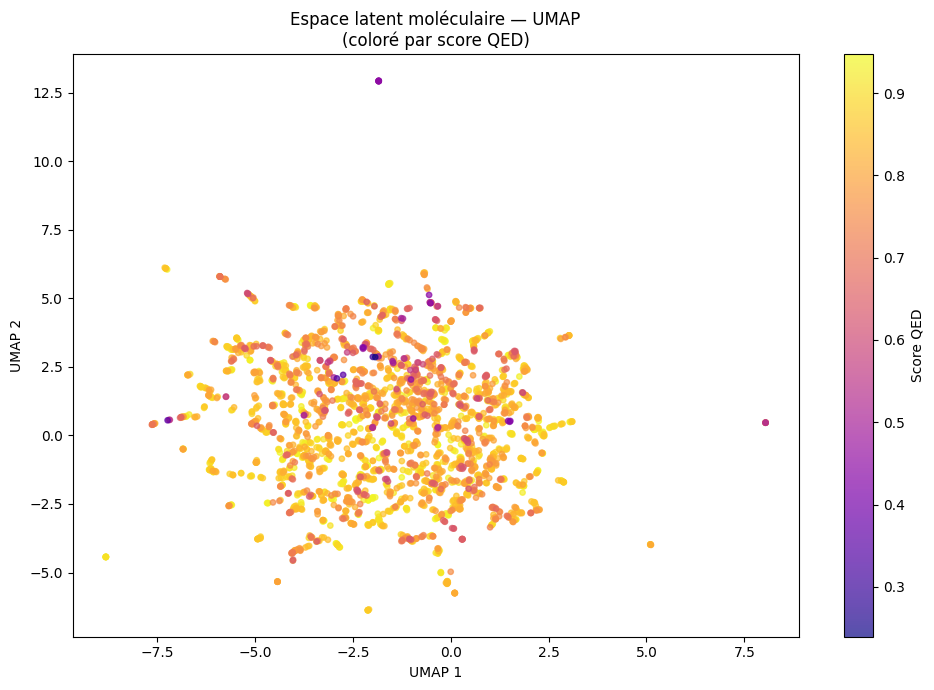

✅ UMAP sauvegardé


In [ ]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

generator = GetMorganGenerator(radius=2, fpSize=2048)

def to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return generator.GetFingerprintAsNumPy(mol)

fps, valid_smiles, valid_qed = [], [], []
for _, row in df_filtered.iterrows():
    fp = to_fp(row['smiles'])
    if fp is not None:
        fps.append(fp)
        valid_smiles.append(row['smiles'])
        valid_qed.append(row['score_QED'])

X = np.array(fps)
qed_values = np.array(valid_qed)

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X)

# Visualisation
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=qed_values, cmap='plasma', s=15, alpha=0.7)
plt.colorbar(scatter, label='Score QED')
plt.title("Espace latent moléculaire — UMAP\n(coloré par score QED)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig("umap_generated.png", dpi=150)
plt.show()
print("✅ UMAP sauvegardé")

In [ ]:
# Visualisation 2D des meilleures molécules

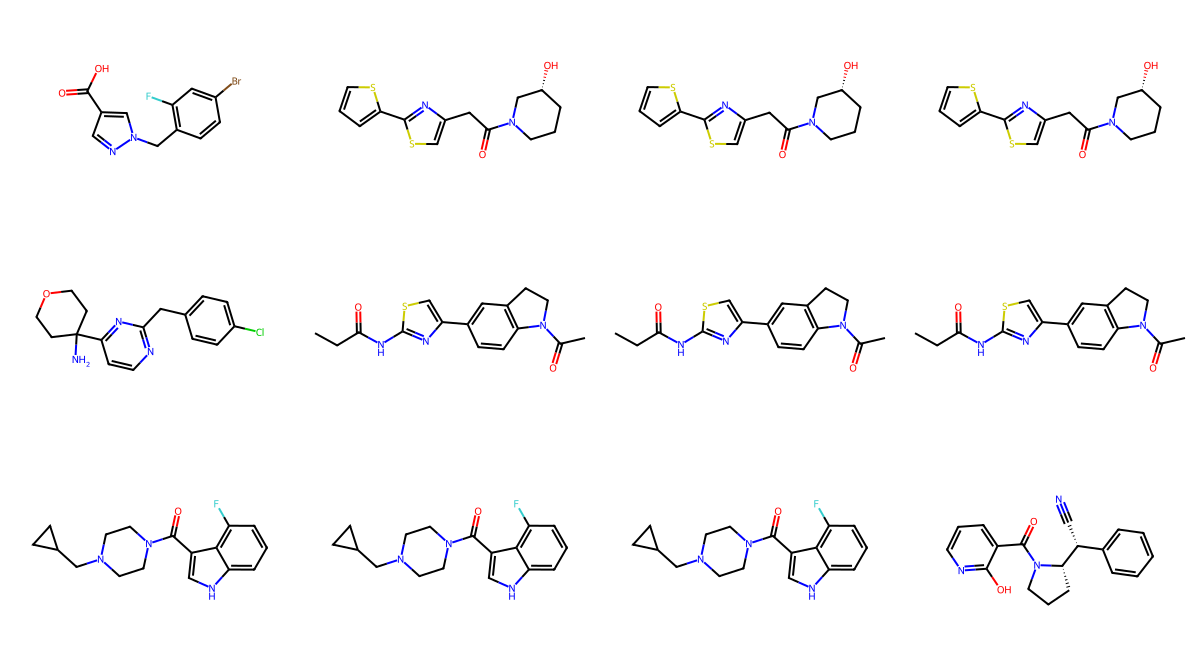

✅ top_molecules.png sauvegardé


In [ ]:
from rdkit.Chem import Draw
from PIL import Image

top_smiles = df_filtered.head(12)['smiles'].tolist()
mols = [Chem.MolFromSmiles(s) for s in top_smiles if Chem.MolFromSmiles(s)]
img = Draw.MolsToGridImage(mols[:12], molsPerRow=4, subImgSize=(300, 220))

# Fix : convertir en PIL image pour sauvegarder
from io import BytesIO
bio = BytesIO(img.data)
pil_img = Image.open(bio)
pil_img.save("top_molecules.png")

# Afficher dans Colab
from IPython.display import display
display(pil_img)
print("✅ top_molecules.png sauvegardé")

In [ ]:
# Enregistrement des résultats

In [ ]:
df_filtered.to_csv('my_filtered_molecules.csv', index=False)
print(f"✅ {len(df_filtered)} molécules sauvegardées")

✅ 2874 molécules sauvegardées


In [ ]:
# Métriques finales

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors

# ── Charger les données ──
df_original = pd.read_csv('generated_molecules.csv')  # 3000 molécules de ton binôme
df_filtered  = pd.read_csv('my_filtered_molecules.csv') # 2874 molécules filtrées par toi

original_set = set(df_original['smiles'].tolist())
gen_smiles   = df_filtered['smiles'].tolist()

# ── Calcul des métriques ──
valid   = [s for s in gen_smiles if Chem.MolFromSmiles(s) is not None]
unique  = list(set(valid))
novel   = [s for s in unique if s not in original_set]

validite  = round(len(valid)  / len(gen_smiles) * 100, 2)
unicite   = round(len(unique) / len(valid)      * 100, 2)
nouveaute = round(len(novel)  / len(unique)     * 100, 2)



# ── QED moyen ──
qed_scores = []
for s in unique:
    mol = Chem.MolFromSmiles(s)
    if mol:
        qed_scores.append(QED.qed(mol))
qed_moyen = round(sum(qed_scores) / len(qed_scores), 3)

# ── SA Score moyen ──
sa_moyen = round(df_filtered['SA_Score'].mean(), 3)

print("=" * 50)
print(f"  Validité       : {validite} %")
print(f"  Unicité        : {unicite} %")
print(f"  Nouveauté      : {nouveaute} %")
print(f"  QED moyen      : {qed_moyen}")
print(f"  SA Score moyen : {sa_moyen}")
print("=" * 50)

# Nouveauté par rapport au dataset ZINC original
df_zinc = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
zinc_set = set(df_zinc['smiles'].tolist())

novel_vs_zinc = [s for s in unique if s not in zinc_set]
nouveaute_zinc = round(len(novel_vs_zinc) / len(unique) * 100, 2)
print(f"Nouveauté vs ZINC original : {nouveaute_zinc} %")

  Validité       : 100.0 %
  Unicité        : 69.03 %
  Nouveauté      : 0.0 %
  QED moyen      : 0.823
  SA Score moyen : 2.667
Nouveauté vs ZINC original : 100.0 %


In [ ]:
# Tableau comparatif avec la littérature

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Tableau comparatif ──
data = {
    'Modèle'      : ['VAE (Kingma)', 'GAN (MolGAN)', 'Diffusion (GDSS)', 'MolMIM NIM (Notre projet)'],
    'Validité (%)'  : [97.7,          94.2,            95.7,               validite],
    'Unicité (%)'   : [67.5,          79.1,            98.5,               unicite],
    'Nouveauté (%)' : [100.0,         99.8,            100.0,              nouveaute_zinc],
    'QED moyen'     : [0.498,         0.554,           0.612,              qed_moyen],
}

df_compare = pd.DataFrame(data)
print(df_compare.to_string(index=False))
df_compare.to_csv('metrics_comparison.csv', index=False)
print("\n Sauvegardé : metrics_comparison.csv")

                   Modèle  Validité (%)  Unicité (%)  Nouveauté (%)  QED moyen
             VAE (Kingma)          97.7        67.50          100.0      0.498
             GAN (MolGAN)          94.2        79.10           99.8      0.554
         Diffusion (GDSS)          95.7        98.50          100.0      0.612
MolMIM NIM (Notre projet)         100.0        69.03          100.0      0.823

 Sauvegardé : metrics_comparison.csv


In [ ]:
# Visualisation du tableau comparatif

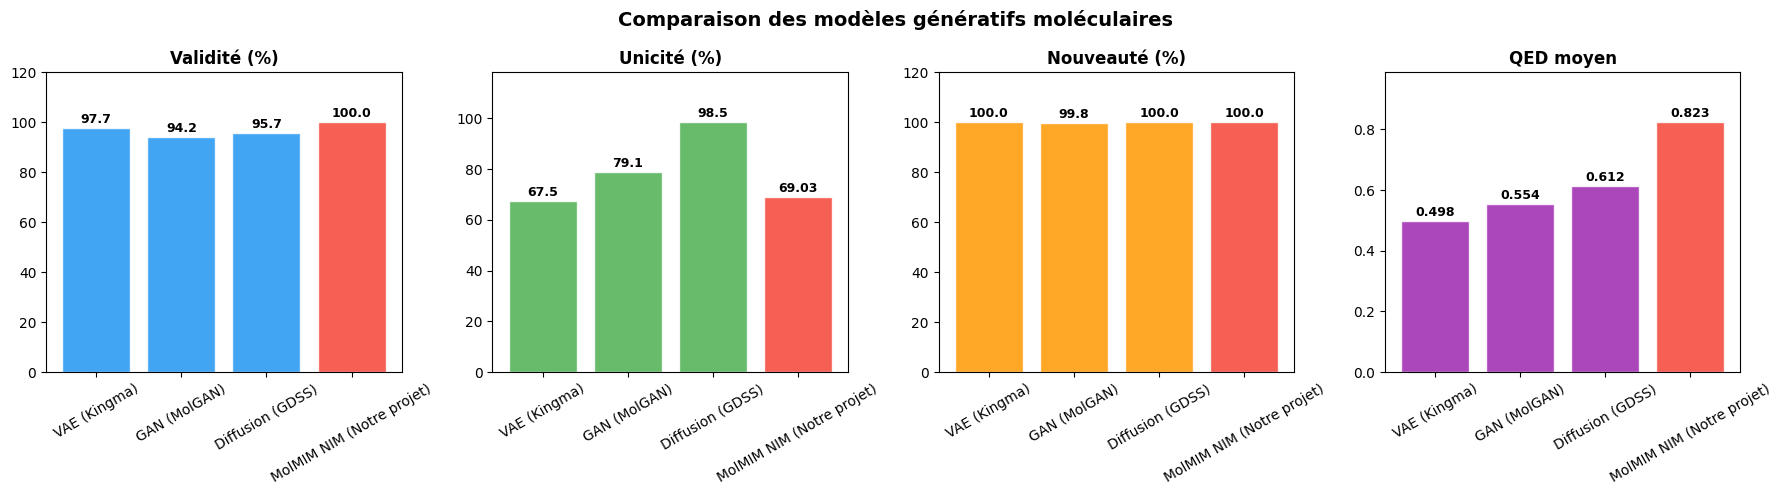

metrics_comparison.png sauvegardé


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparaison des modèles génératifs moléculaires', fontsize=14, fontweight='bold')

metrics  = ['Validité (%)', 'Unicité (%)', 'Nouveauté (%)', 'QED moyen']
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
modeles  = df_compare['Modèle'].tolist()

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals  = df_compare[metric].tolist()
    bars  = axes[i].bar(modeles, vals, color=[color]*3 + ['#F44336'], alpha=0.85, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0, max(vals) * 1.2)
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.02,
                     str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("metrics_comparison.png sauvegardé")

In [ ]:
!pip install rdkit xgboost scikit-learn matplotlib seaborn -q

In [ ]:
#Création des labels de toxicité

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.FilterCatalog import FilterCatalogParams, FilterCatalog
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

df = pd.read_csv('my_filtered_molecules.csv')
print(f" {len(df)} molécules chargées")

# ── Créer labels toxicité automatiquement ──
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

toxic_smarts = [
    '[N+](=O)[O-]',   # Nitro
    'c1ccccc1N',      # Aniline
    '[SH]',           # Thiol
    'C(=O)Cl',        # Acyl chloride
    'N=N',            # Azo
    '[$(C-Cl)]',      # Chlore aliphatique
    'C1OC1',          # Epoxide
]

def label_toxicity(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Vérifier groupes toxiques
    for smarts in toxic_smarts:
        pattern = Chem.MolFromSmarts(smarts)
        if pattern and mol.HasSubstructMatch(pattern):
            return 1  # TOXIQUE

    # Vérifier PAINS
    if catalog.HasMatch(mol):
        return 1  # TOXIQUE

    # Vérifier propriétés extrêmes
    logp = Descriptors.MolLogP(mol)
    mw   = Descriptors.MolWt(mol)
    if logp > 5 or mw > 500:
        return 1  # TOXIQUE

    return 0  # NON-TOXIQUE

print("Création des labels...")
df['Toxicity'] = df['smiles'].apply(label_toxicity)
df = df.dropna(subset=['Toxicity'])
df['Toxicity'] = df['Toxicity'].astype(int)

print(f"\n Distribution des labels :")
print(f"   Non-toxique (0) : {(df['Toxicity']==0).sum()}")
print(f"   Toxique    (1) : {(df['Toxicity']==1).sum()}")
print(f"  Ratio toxique : {(df['Toxicity']==1).mean()*100:.1f}%")

 2874 molécules chargées
Création des labels...

 Distribution des labels :
   Non-toxique (0) : 1991
   Toxique    (1) : 883
  Ratio toxique : 30.7%


In [ ]:
#Extraire les features

In [ ]:
generator = GetMorganGenerator(radius=2, fpSize=1024)

def extract_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Morgan Fingerprint (1024 bits)
    fp = generator.GetFingerprintAsNumPy(mol)

    # Propriétés physico-chimiques
    props = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        mol.GetNumHeavyAtoms(),
        rdMolDescriptors.CalcFractionCSP3(mol),
        Descriptors.MolMR(mol),
    ])

    return np.concatenate([fp, props])

print(" Extraction des features...")
X_list, y_list, valid_smiles = [], [], []

for _, row in df.iterrows():
    feat = extract_features(row['smiles'])
    if feat is not None:
        X_list.append(feat)
        y_list.append(row['Toxicity'])
        valid_smiles.append(row['smiles'])

X = np.array(X_list)
y = np.array(y_list)

print(f"  Features shape : {X.shape}")
print(f"   → {1024} bits fingerprint + 10 propriétés = {X.shape[1]} features total")

 Extraction des features...
  Features shape : (2874, 1034)
   → 1024 bits fingerprint + 10 propriétés = 1034 features total


In [ ]:
#Split Train/Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} molécules")
print(f"Test  : {X_test.shape[0]} molécules")
print(f"Train toxique : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test  toxique : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train : 2299 molécules
Test  : 575 molécules
Train toxique : 706 (30.7%)
Test  toxique : 177 (30.8%)


In [ ]:
#Entraîner et comparer les 3 modèles

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             confusion_matrix)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),

}

results = {}
trained_models = {}

print("Entraînement des modèles...\n")
for name, model in models.items():
    print(f"   {name}...")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_proba), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
    }
    trained_models[name] = model
    print(f"     Accuracy : {results[name]['Accuracy']}%")
    print(f"     AUC-ROC  : {results[name]['AUC-ROC']}")
    print(f"     F1-Score : {results[name]['F1-Score']}\n")

# ── Tableau comparatif ──
df_results = pd.DataFrame(results).T
print("=" * 50)
print(" COMPARAISON DES MODÈLES :")
print("=" * 50)
print(df_results.to_string())
print("=" * 50)

Entraînement des modèles...

   Random Forest...
     Accuracy : 97.74%
     AUC-ROC  : 0.9912
     F1-Score : 0.9625

   XGBoost...
     Accuracy : 98.78%
     AUC-ROC  : 0.9885
     F1-Score : 0.9799

 COMPARAISON DES MODÈLES :
               Accuracy  AUC-ROC  F1-Score
Random Forest     97.74   0.9912    0.9625
XGBoost           98.78   0.9885    0.9799


In [ ]:
#Visualisations comparatives

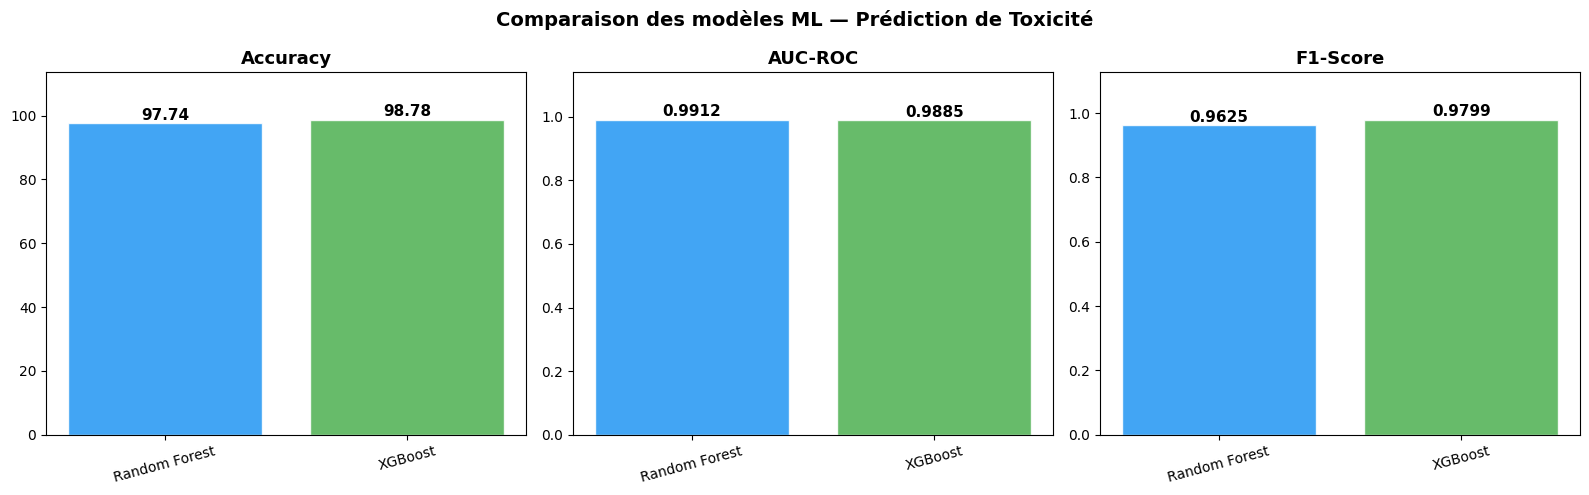

models_comparison.png sauvegardé


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles ML — Prédiction de Toxicité',
             fontsize=14, fontweight='bold')

metrics  = ['Accuracy', 'AUC-ROC', 'F1-Score']
colors   = ['#2196F3', '#4CAF50', '#FF9800']
model_names = list(results.keys())

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, vals,
                       color=colors, alpha=0.85, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_ylim(0, max(vals) * 1.15)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals)*0.01,
            str(val), ha='center', fontsize=11, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("models_comparison.png sauvegardé")

In [ ]:
#Choisir le meilleur modèle + Matrice de confusion

 Meilleur modèle : Random Forest
   AUC-ROC  : 0.9912
   Accuracy : 97.74%
   F1-Score : 0.9625

 Rapport de classification (Random Forest) :
              precision    recall  f1-score   support

 Non-toxique       0.98      0.99      0.98       398
     Toxique       0.98      0.94      0.96       177

    accuracy                           0.98       575
   macro avg       0.98      0.97      0.97       575
weighted avg       0.98      0.98      0.98       575



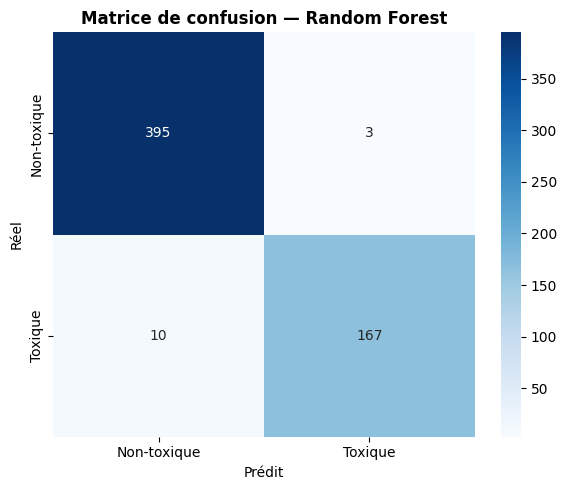


  Meilleur modèle sauvegardé : best_toxicity_model.pkl


In [ ]:
# ── Meilleur modèle selon AUC-ROC ──
best_name = max(results, key=lambda m: results[m]['AUC-ROC'])
best_model = trained_models[best_name]

print(f" Meilleur modèle : {best_name}")
print(f"   AUC-ROC  : {results[best_name]['AUC-ROC']}")
print(f"   Accuracy : {results[best_name]['Accuracy']}%")
print(f"   F1-Score : {results[best_name]['F1-Score']}")

# ── Rapport détaillé ──
y_pred_best = best_model.predict(X_test)
print(f"\n Rapport de classification ({best_name}) :")
print(classification_report(y_test, y_pred_best,
      target_names=['Non-toxique', 'Toxique']))

# ── Matrice de confusion ──
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-toxique', 'Toxique'],
            yticklabels=['Non-toxique', 'Toxique'])
plt.title(f'Matrice de confusion — {best_name}', fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Sauvegarder le meilleur modèle ──
joblib.dump(best_model, 'best_toxicity_model.pkl')
joblib.dump({'X': X, 'y': y, 'smiles': valid_smiles}, 'features_data.pkl')
print(f"\n  Meilleur modèle sauvegardé : best_toxicity_model.pkl")

In [ ]:
#Prédire la toxicité sur les molécules générées

In [ ]:
print(" Prédiction sur les molécules générées...")

predictions = []
for smi in df['smiles']:
    feat = extract_features(smi)
    if feat is None:
        continue
    feat = feat.reshape(1, -1)
    pred  = best_model.predict(feat)[0]
    proba = best_model.predict_proba(feat)[0][1]

    predictions.append({
        'smiles'         : smi,
        'score_QED'      : df[df['smiles']==smi]['score_QED'].values[0],
        'SA_Score'       : df[df['smiles']==smi]['SA_Score'].values[0],
        'Tox_Prediction' : int(pred),
        'Tox_Probability': round(proba, 3),
        'Tox_Label'      : ' TOXIQUE' if pred == 1 else 'NON-TOXIQUE',
        'Tox_Color'      : 'red' if pred == 1 else 'green',
    })

df_final = pd.DataFrame(predictions)
df_final.to_csv('molecules_ml_toxicity.csv', index=False)

print("\n Résultats finaux :")
print(f"   Non-toxiques : {(df_final['Tox_Prediction']==0).sum()}")
print(f"   Toxiques     : {(df_final['Tox_Prediction']==1).sum()}")
print(f"\n Top 5 meilleures molécules non-toxiques :")
top5 = df_final[df_final['Tox_Prediction']==0]\
       .sort_values('score_QED', ascending=False).head(5)
print(top5[['smiles','score_QED','Tox_Probability','Tox_Label']].to_string())

 Prédiction sur les molécules générées...

 Résultats finaux :
   Non-toxiques : 1998
   Toxiques     : 876

 Top 5 meilleures molécules non-toxiques :
                                    smiles  score_QED  Tox_Probability    Tox_Label
0            O=C(O)c1cnn(Cc2ccc(Br)cc2F)c1   0.947229             0.01  NON-TOXIQUE
1  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070             0.03  NON-TOXIQUE
3  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070             0.03  NON-TOXIQUE
2  O=C(Cc1csc(-c2cccs2)n1)N1CCC[C@@H](O)C1   0.947070             0.03  NON-TOXIQUE
4       NC1(c2ccnc(Cc3ccc(Cl)cc3)n2)CCOCC1   0.946784             0.04  NON-TOXIQUE


Calcul des SHAP values (1-2 min)...
✅ SHAP values shape : (575, 1034)


/tmp/ipykernel_8202/615481831.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8202/615481831.py:65: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8202/615481831.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('shap_global.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
/tmp/ipykernel_8202/615481831.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('shap_global.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE G

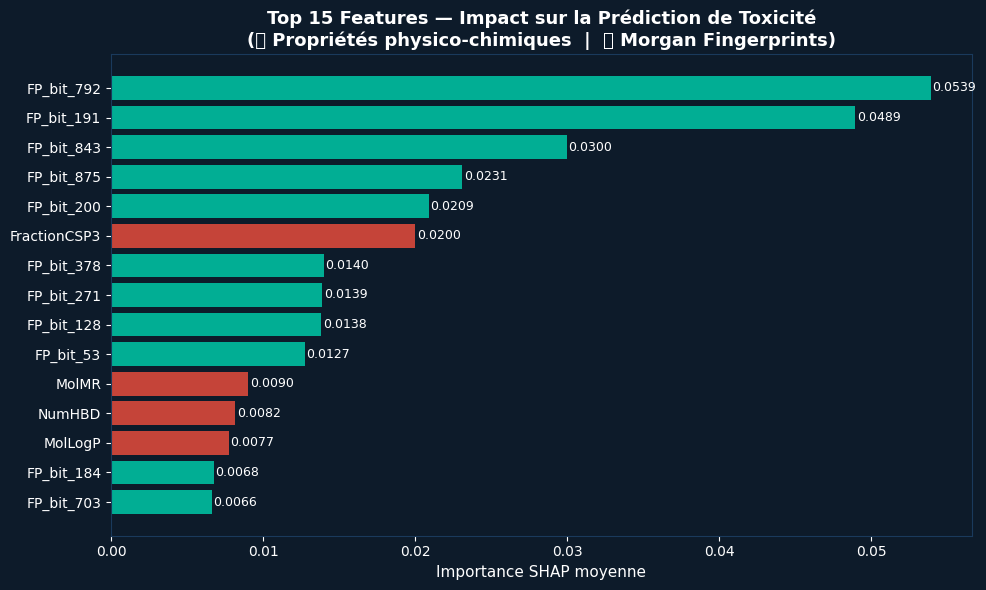

/tmp/ipykernel_8202/615481831.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8202/615481831.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


✅ shap_global.png sauvegardé


/tmp/ipykernel_8202/615481831.py:99: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('shap_local.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
/tmp/ipykernel_8202/615481831.py:99: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('shap_local.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


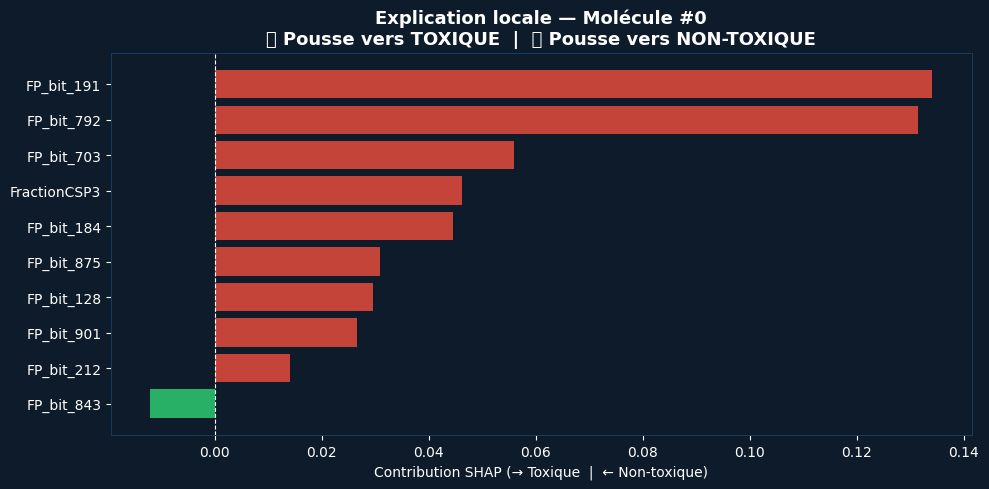

✅ shap_local.png sauvegardé


[10:19:36] DEPRECATION WARNING: please use MorganGenerator


[10:19:36] SMARTS Parse Error: syntax error while parsing: [[N+](=O)[O-]:1]
[10:19:36] SMARTS Parse Error: check for mistakes around position 2:
[10:19:36] [[N+](=O)[O-]:1]
[10:19:36] ~^


✅ Highlight atomes affiché

  ANALYSE COUNTERFACTUELLE
  Molécule : CCC(=O)Nc1nc(-c2ccc3c(c2)CCN3C(C)=O)cs1...
  P(Toxique) initiale : 80.0%

  Modification                  P(original)  P(modifiée)        Δ
  --------------------------------------------------------------


[10:19:36] SMARTS Parse Error: Failed parsing SMARTS '[[N+](=O)[O-]:1]' for input: '[[N+](=O)[O-]:1]'
[10:19:36] SMARTS Parse Error: syntax error while parsing: [[N+](=O)[O-]:1]
[10:19:36] SMARTS Parse Error: check for mistakes around position 2:
[10:19:36] [[N+](=O)[O-]:1]
[10:19:36] ~^
[10:19:36] SMARTS Parse Error: Failed parsing SMARTS '[[N+](=O)[O-]:1]' for input: '[[N+](=O)[O-]:1]'
[10:19:36] SMARTS Parse Error: syntax error while parsing: [[SH]:1]
[10:19:36] SMARTS Parse Error: check for mistakes around position 2:
[10:19:36] [[SH]:1]
[10:19:36] ~^
[10:19:36] SMARTS Parse Error: Failed parsing SMARTS '[[SH]:1]' for input: '[[SH]:1]'
[10:19:36] SMARTS Parse Error: syntax error while parsing: [N=N:1]
[10:19:36] SMARTS Parse Error: check for mistakes around position 3:
[10:19:36] [N=N:1]
[10:19:36] ~~^
[10:19:36] SMARTS Parse Error: Failed parsing SMARTS '[N=N:1]' for input: '[N=N:1]'


In [ ]:
#shap
# ══════════════════════════════════════════════════════════════
# SHAP + Highlight Atomes + Counterfactual
# ══════════════════════════════════════════════════════════════
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, HTML, Image as IPImage
from io import BytesIO

# ── Noms des features ──
FEATURE_NAMES = (
    [f'FP_bit_{i}' for i in range(1024)] +
    ['MolWt', 'MolLogP', 'TPSA', 'NumHBD', 'NumHBA',
     'RotatableBonds', 'AromaticRings', 'HeavyAtoms',
     'FractionCSP3', 'MolMR']
)

# ══════════════════════════════════════
# 1. SHAP GLOBAL — Top 15 features
# ══════════════════════════════════════
print("Calcul des SHAP values (1-2 min)...")
explainer   = shap.TreeExplainer(trained_models['Random Forest'])
shap_values = explainer.shap_values(X_test)

# Extraction robuste selon version SHAP
if isinstance(shap_values, list):
    sv_toxic = np.array(shap_values[1])
elif np.array(shap_values).ndim == 3:
    sv_toxic = np.array(shap_values)[:, :, 1]
else:
    sv_toxic = np.array(shap_values)

print(f"✅ SHAP values shape : {sv_toxic.shape}")

mean_shap   = np.abs(sv_toxic).mean(axis=0)
top15_idx   = np.argsort(mean_shap)[-15:][::-1].tolist()
top15_names = [FEATURE_NAMES[i] for i in top15_idx]
top15_vals  = np.array([mean_shap[i] for i in top15_idx])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0D1B2A')
ax.set_facecolor('#0D1B2A')
colors = ['#e74c3c' if 'FP' not in n else '#00C9A7' for n in top15_names]
ax.barh(range(15), top15_vals[::-1], color=colors[::-1], alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_names[::-1], color='white', fontsize=10)
ax.set_xlabel('Importance SHAP moyenne', color='white', fontsize=11)
ax.set_title('Top 15 Features — Impact sur la Prédiction de Toxicité\n'
             '(🔴 Propriétés physico-chimiques  |  🟢 Morgan Fingerprints)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#1A3A5C')
for bar, val in zip(ax.patches, top15_vals[::-1]):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("✅ shap_global.png sauvegardé")

# ══════════════════════════════════════
# 2. SHAP LOCAL — Molécule toxique
# ══════════════════════════════════════
toxic_indices = np.where(y_test == 1)[0]
idx = toxic_indices[0]

# Extraction 1D robuste
sv_mol = sv_toxic[idx].flatten()

top10_idx   = np.argsort(np.abs(sv_mol))[-10:][::-1].tolist()
top10_names = [FEATURE_NAMES[i] for i in top10_idx]
top10_shap  = np.array([sv_mol[i] for i in top10_idx])

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1B2A')
ax.set_facecolor('#0D1B2A')
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top10_shap[::-1]]
ax.barh(range(10), top10_shap[::-1], color=bar_colors, alpha=0.85)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_names[::-1], color='white', fontsize=10)
ax.set_xlabel('Contribution SHAP (→ Toxique  |  ← Non-toxique)', color='white')
ax.set_title(f'Explication locale — Molécule #{idx}\n'
              '🔴 Pousse vers TOXIQUE  |  🟢 Pousse vers NON-TOXIQUE',
             color='white', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='white', linewidth=0.8, linestyle='--')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#1A3A5C')
plt.tight_layout()
plt.savefig('shap_local.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("✅ shap_local.png sauvegardé")

# ══════════════════════════════════════
# 3. HIGHLIGHT ATOMES
# ══════════════════════════════════════
df_tox_loaded = pd.read_csv('molecules_ml_toxicity.csv')
smiles_toxic  = df_tox_loaded[df_tox_loaded['Tox_Prediction']==1].iloc[0]['smiles']
mol_toxic     = Chem.MolFromSmiles(smiles_toxic)

info = {}
rdMolDescriptors.GetMorganFingerprint(mol_toxic, 2, bitInfo=info)

fp_shap_pos = [(i, sv_mol[i]) for i, name in enumerate(FEATURE_NAMES)
               if 'FP_bit_' in name and sv_mol[i] > 0]
fp_shap_pos.sort(key=lambda x: x[1], reverse=True)
top_bits = [int(FEATURE_NAMES[i].replace('FP_bit_', '')) for i, _ in fp_shap_pos[:8]]

highlight_atoms = set()
for bit in top_bits:
    if bit in info:
        for atom_idx, radius in info[bit]:
            highlight_atoms.add(atom_idx)

drawer = rdMolDraw2D.MolDraw2DSVG(500, 400)
rdMolDraw2D.PrepareMolForDrawing(mol_toxic)
drawer.DrawMolecule(
    mol_toxic,
    highlightAtoms=list(highlight_atoms),
    highlightAtomColors={a: (0.9, 0.2, 0.2) for a in highlight_atoms},
    highlightBonds=[],
    highlightBondColors={}
)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

display(HTML(f"""
<div style='background:#0D1B2A;padding:20px;border-radius:10px;border:1px solid #00C9A7;display:inline-block'>
    <h3 style='color:#00C9A7;font-family:Calibri'>🔬 Atomes responsables de la toxicité</h3>
    <p style='color:#CBD5E1'>
        Les atomes <span style='color:#e74c3c;font-weight:bold'>surlignés en rouge</span>
        correspondent aux sous-structures dont les Morgan Fingerprints
        contribuent le plus à la prédiction <b style='color:#e74c3c'>TOXIQUE</b>.
    </p>
    {svg}
    <p style='color:gray;font-size:12px'>SMILES : {smiles_toxic}</p>
</div>
"""))
print("✅ Highlight atomes affiché")

# ══════════════════════════════════════
# 4. COUNTERFACTUAL
# ══════════════════════════════════════
from rdkit.Chem import AllChem

gen_cf = GetMorganGenerator(radius=2, fpSize=1024)

def extract_features_cf(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    fp = gen_cf.GetFingerprintAsNumPy(mol)
    props = np.array([
        Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol), rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        mol.GetNumHeavyAtoms(), rdMolDescriptors.CalcFractionCSP3(mol),
        Descriptors.MolMR(mol),
    ])
    return np.concatenate([fp, props])

modifications = [
    ('[N+](=O)[O-]', 'O',   'Nitro → Hydroxyle'),
    ('[N+](=O)[O-]', 'N',   'Nitro → Amine'),
    ('Cl',           'F',   'Chlore → Fluor'),
    ('Cl',           'O',   'Chlore → Hydroxyle'),
    ('[SH]',         'O',   'Thiol → Hydroxyle'),
    ('N=N',          'C=C', 'Azo → Alcène'),
]

feat_orig = extract_features_cf(smiles_toxic)
p_orig = round(best_model.predict_proba([feat_orig])[0][1] * 100, 1)

print(f"\n{'='*55}")
print(f"  ANALYSE COUNTERFACTUELLE")
print(f"{'='*55}")
print(f"  Molécule : {smiles_toxic[:60]}...")
print(f"  P(Toxique) initiale : {p_orig}%\n")
print(f"  {'Modification':<28} {'P(original)':>12} {'P(modifiée)':>12} {'Δ':>8}")
print(f"  {'-'*62}")

results_cf = []
for smarts_from, smarts_to, desc in modifications:
    try:
        rxn = AllChem.ReactionFromSmarts(f'[{smarts_from}:1]>>[{smarts_to}:1]')
        products = rxn.RunReactants((mol_toxic,))
        if not products: continue
        smi_new = Chem.MolToSmiles(products[0][0])
        feat_new = extract_features_cf(smi_new)
        if feat_new is None: continue
        p_new = round(best_model.predict_proba([feat_new])[0][1] * 100, 1)
        delta = round(p_new - p_orig, 1)
        results_cf.append((desc, smi_new, p_new, delta))
        arrow = "📉" if delta < 0 else "📈"
        print(f"  {desc:<28} {p_orig:>11}% {p_new:>11}% {delta:>+6}% {arrow}")
    except:
        continue

if results_cf:
    best_cf = min(results_cf, key=lambda x: x[2])
    desc_b, smi_b, p_b, delta_b = best_cf
    mol_b = Chem.MolFromSmiles(smi_b)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#0D1B2A')
    fig.suptitle(f'Counterfactual — Meilleure modification : {desc_b}',
                 color='white', fontsize=13, fontweight='bold')
    axes[0].imshow(Draw.MolToImage(mol_toxic, size=(300,250)))
    axes[0].axis('off'); axes[0].set_facecolor('#0D1B2A')
    axes[0].set_title(f'Originale\nP(Toxique) = {p_orig}%', color='#e74c3c', fontweight='bold')
    if mol_b:
        axes[1].imshow(Draw.MolToImage(mol_b, size=(300,250)))
    axes[1].axis('off'); axes[1].set_facecolor('#0D1B2A')
    axes[1].set_title(f'Après {desc_b}\nP(Toxique) = {p_b}%  ({delta_b:+}%)', color='#2ecc71', fontweight='bold')
    plt.tight_layout()
    plt.savefig('counterfactual.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
    plt.show()
    print(f"\n✅ counterfactual.png sauvegardé")
    print(f"✅ Meilleure modification : {desc_b} → P(tox) {p_orig}% → {p_b}%")

In [ ]:
#app.py

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, QED, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ══════════════════════════════════════════════════════════════
# 1. CONFIGURATION & DESIGN CSS (LOOK MASTER DS)
# ══════════════════════════════════════════════════════════════
st.set_page_config(page_title="AI Molecular Discovery Lab", page_icon="🧬", layout="wide")

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap');

    .stApp {
        background: radial-gradient(circle at 20% 20%, #0d1b2a 0%, #010409 100%);
        color: #e2e8f0;
        font-family: 'Inter', sans-serif;
    }

    /* Header Container */
    .header-container {
        background: rgba(255, 255, 255, 0.03);
        border: 1px solid rgba(255, 255, 255, 0.1);
        backdrop-filter: blur(10px);
        padding: 40px; border-radius: 24px; margin-bottom: 30px;
        text-align: center; border-bottom: 4px solid #00d4ff;
    }

    /* Cartes de métriques */
    .metric-card {
        background: rgba(255, 255, 255, 0.04);
        border: 1px solid rgba(255, 255, 255, 0.1);
        border-radius: 20px; padding: 24px; text-align: center;
        transition: all 0.3s ease;
    }
    .metric-card:hover { transform: translateY(-8px); border-color: #00d4ff; }
    .metric-value { font-size: 2.2em; font-weight: 700; color: #00d4ff; }
    .metric-label { font-size: 0.9em; color: #94a3b8; text-transform: uppercase; letter-spacing: 1.5px; }

    /* Titres Labo */
    .section-title {
        font-size: 1.5em; font-weight: 600; color: #00d4ff;
        border-left: 6px solid #00d4ff; padding-left: 20px; margin: 35px 0 20px 0;
    }

    /* Tabs Decoration */
    .stTabs [data-baseweb="tab-list"] { gap: 12px; }
    .stTabs [data-baseweb="tab"] {
        background-color: rgba(255, 255, 255, 0.03);
        border-radius: 12px 12px 0 0; padding: 12px 24px; color: #94a3b8;
    }
    .stTabs [aria-selected="true"] { background-color: #00d4ff !important; color: #000 !important; font-weight: bold; }
</style>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════
# 2. CHARGEMENT DES DONNÉES & FONCTIONS UTILES
# ══════════════════════════════════════════════════════════════
@st.cache_data
def load_data():
    try:
        return pd.read_csv('generated_molecules.csv'), pd.read_csv('my_filtered_molecules.csv'), pd.read_csv('molecules_ml_toxicity.csv')
    except:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

@st.cache_resource
def load_model():
    try: return joblib.load('best_toxicity_model.pkl')
    except: return None

df_gen, df_filtered, df_tox = load_data()
best_model = load_model()

FEATURE_NAMES = [f'FP_bit_{i}' for i in range(1024)] + ['MolWt','MolLogP','TPSA','NumHBD','NumHBA','RotatableBonds','AromaticRings','HeavyAtoms','FractionCSP3','MolMR']

CF_MODIFICATIONS = [
    ('[N+:1](=[O:2])[O-:3]>>[OH:1]',   'Nitro → Hydroxyle'),
    ('[N+:1](=[O:2])[O-:3]>>[NH2:1]',  'Nitro → Amine'),
    ('[Cl:1]>>[F:1]',                   'Chlore → Fluor'),
    ('[Cl:1]>>[OH:1]',                  'Chlore → Hydroxyle'),
    ('[S:1][H]>>[O:1][H]',              'Thiol → Hydroxyle'),
    ('[N:1]=[N:2]>>[C:1]=[C:2]',       'Azo → Alcène'),
]

def extract_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    fp = GetMorganGenerator(radius=2, fpSize=1024).GetFingerprintAsNumPy(mol)
    props = np.array([Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol), rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol), rdMolDescriptors.CalcNumAromaticRings(mol),
        mol.GetNumHeavyAtoms(), rdMolDescriptors.CalcFractionCSP3(mol), Descriptors.MolMR(mol)])
    return np.concatenate([fp, props])

# ══════════════════════════════════════════════════════════════
# 3. SIDEBAR & HEADER
# ══════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("### ⚙️ FILTRES")
    qed_min = st.slider("QED minimum", 0.0, 1.0, 0.7, 0.01)
    sa_max = st.slider("SA Score max", 1.0, 5.0, 3.0, 0.1)
    tox_only = st.radio("Toxicité", ["Toutes", "Non-toxiques ✅", "Toxiques ❌"])
    n_show = st.slider("Molécules à afficher", 4, 32, 12, 4)
    st.markdown("---")
    st.info(f"📊 **Dataset :** {len(df_gen)} mol. générées")

st.markdown(f"""<div class="header-container">
    <h1 style='margin:0; font-size:2.8em; color:#00d4ff;'>🧬 DE NOVO MOLECULAR GENERATION</h1>
    <p style='margin:12px 0 0; color:#94a3b8; font-size:1.2em;'>Génération · Filtrage · Prédiction de Toxicité ML</p>
    <p style='color:#4a5568; font-size:0.9em; margin-top:8px;'>Master Big Data & DS | FSBM Hassan II Casablanca · 2025-2026</p>
</div>""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════
# 4. LES 5 ONGLETS
# ══════════════════════════════════════════════════════════════
if df_tox.empty:
    st.error("Données introuvables. Veuillez vérifier vos fichiers CSV.")
else:
    tab1, tab2, tab3, tab4, tab5 = st.tabs(["📊 Vue globale", "🔬 Molécules", "🗺️ Espace latent", "☠️ Toxicité ML", "📋 Données"])

    # --- ONGLET 1 : VUE GLOBALE ---
    with tab1:
        st.markdown('<div class="section-title">Indicateurs de Performance</div>', unsafe_allow_html=True)
        cols = st.columns(5)
        for col, (v,l) in zip(cols, [("100%","Validité"),("69%","Unicité"),("100%","Nouveauté"),("0.823","QED moyen"),("2.667","SA Score")]):
            col.markdown(f'<div class="metric-card"><div class="metric-value">{v}</div><div class="metric-label">{l}</div></div>', unsafe_allow_html=True)

        st.markdown('<div class="section-title">Comparaison vs État de l\'Art</div>', unsafe_allow_html=True)
        c1, c2 = st.columns(2)
        with c1:
            df_lit = pd.DataFrame({'Modèle':['VAE','GAN','GDSS','🏆 MolMIM (NIM)'],'QED':[0.50, 0.55, 0.61, 0.82]})
            st.dataframe(df_lit, use_container_width=True, hide_index=True)
        with c2:
            fig, ax = plt.subplots(figsize=(7, 4)); fig.patch.set_alpha(0); ax.set_facecolor('none')
            ax.bar(df_lit['Modèle'], df_lit['QED'], color=['#1e293b','#1e293b','#1e293b','#00d4ff'])
            ax.tick_params(colors='white'); st.pyplot(fig)

    # --- ONGLET 2 : MOLÉCULES (GALLERY) ---
    with tab2:
        st.markdown('<div class="section-title">Candidats Moléculaires</div>', unsafe_allow_html=True)
        dv = df_tox[(df_tox['score_QED']>=qed_min) & (df_tox['SA_Score']<=sa_max)]
        if tox_only=="Non-toxiques ✅": dv = dv[dv['Tox_Prediction']==0]
        elif tox_only=="Toxiques ❌": dv = dv[dv['Tox_Prediction']==1]

        st.markdown(f"<p style='color: #94a3b8; font-style: italic;'>{len(dv)} molécules correspondent aux filtres</p>", unsafe_allow_html=True)

        mols = [Chem.MolFromSmiles(s) for s in dv.head(n_show)['smiles'] if Chem.MolFromSmiles(s)]
        if mols:
            img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250,200), legends=[f"QED: {r['score_QED']:.2f}" for i,r in dv.head(n_show).iterrows()])
            st.markdown('<div style="background: white; border-radius: 15px; padding: 10px;">', unsafe_allow_html=True)
            st.image(img, use_container_width=True)
            st.markdown('</div>', unsafe_allow_html=True)
            st.download_button("⬇️ Télécharger cette sélection", data=dv.to_csv(index=False).encode(), file_name='selection.csv')

    # --- ONGLET 3 : ESPACE LATENT ---
    with tab3:
        st.markdown('<div class="section-title">Visualisation de la Diversité Chimique</div>', unsafe_allow_html=True)
        try: st.image("umap_generated.png", use_container_width=True)
        except: st.info("Image UMAP manquante.")

    # --- ONGLET 4 : TOXICITÉ ML (XAI) ---
    with tab4:
        st.markdown('<div class="section-title">Predictor & Explainable AI (XAI)</div>', unsafe_allow_html=True)
        user_smi = st.text_input("🔬 Entrer un SMILES pour analyse temps-réel", "C1=CC=C(C=C1)[N+](=O)[O-]")

        if user_smi and best_model:
            mol = Chem.MolFromSmiles(user_smi)
            if mol:
                feat = extract_features(user_smi).reshape(1,-1)
                prob = best_model.predict_proba(feat)[0][1]

                c1, c2 = st.columns(2)
                with c1:
                    clr = "#ef4444" if prob > 0.5 else "#10b981"
                    st.markdown(f"""<div style='border:2px solid {clr}; border-radius:20px; padding:35px; text-align:center; background:{clr}11'>
                        <h1 style='color:{clr}; margin:0'>{'TOXIQUE' if prob > 0.5 else 'SÛR'}</h1>
                        <p style='font-size:1.4em; margin-top:10px;'>Probabilité : {prob*100:.1f}%</p>
                    </div>""", unsafe_allow_html=True)
                with c2: st.image(Draw.MolToImage(mol, size=(350,300)))

                st.markdown("---")
                # SHAP + HIGHLIGHT
                col_sh, col_at = st.columns(2)
                with col_sh:
                    st.markdown("### 🧠 Pourquoi ce score ? (SHAP)")
                    explainer = shap.TreeExplainer(best_model)
                    shap_v = explainer.shap_values(feat)
                    sv_plot = shap_v[1][0] if isinstance(shap_v, list) else shap_v[0,:,1] if len(shap_v.shape)==3 else shap_v[0]
                    idx = np.argsort(np.abs(sv_plot))[-10:]
                    fig, ax = plt.subplots(figsize=(8,5)); fig.patch.set_alpha(0); ax.set_facecolor('none')
                    ax.barh([FEATURE_NAMES[i] for i in idx], sv_plot[idx], color=['#ef4444' if x>0 else '#10b981' for x in sv_plot[idx]])
                    ax.tick_params(colors='white'); st.pyplot(fig)

                with col_at:
                    st.markdown("### 🔴 Atomes suspects")
                    info = {}; rdMolDescriptors.GetMorganFingerprint(mol, 2, bitInfo=info)
                    fp_pos = sorted([(i, sv_plot[i]) for i,n in enumerate(FEATURE_NAMES) if 'FP_bit_' in n and sv_plot[i]>0.01], key=lambda x: x[1], reverse=True)
                    h_atoms = set()
                    for bit_idx, _ in fp_pos[:5]:
                        b_id = int(FEATURE_NAMES[bit_idx].replace('FP_bit_',''))
                        if b_id in info:
                            for aidx, _ in info[b_id]: h_atoms.add(aidx)
                    drw = rdMolDraw2D.MolDraw2DSVG(450, 350)
                    rdMolDraw2D.PrepareMolForDrawing(mol)
                    drw.DrawMolecule(mol, highlightAtoms=list(h_atoms), highlightAtomColors={a:(0.9,0.2,0.2) for a in h_atoms})
                    drw.FinishDrawing()
                    st.markdown(f"<div style='background:white; border-radius:15px; padding:10px; text-align:center;'>{drw.GetDrawingText()}</div>", unsafe_allow_html=True)

                # --- COUNTERFACTUAL + CONCLUSION ---
                st.markdown("### 🟢 Solutions d'optimisation (Counterfactual)")
                results_cf = []
                for rs, desc in CF_MODIFICATIONS:
                    try:
                        rxn = AllChem.ReactionFromSmarts(rs)
                        prods = rxn.RunReactants((mol,))
                        if prods:
                            s_n = Chem.MolToSmiles(prods[0][0]); f_n = extract_features(s_n)
                            p_n = best_model.predict_proba([f_n])[0][1]
                            results_cf.append({"Modification": desc, "P(tox) Nouvelle": p_n * 100, "Impact": (p_n - prob) * 100})
                    except: continue

                if results_cf:
                    df_cf = pd.DataFrame(results_cf)
                    best_opt = df_cf.loc[df_cf['P(tox) Nouvelle'].idxmin()]
                    st.markdown(f"""
                        <div style='background: rgba(16, 185, 129, 0.1); border: 1px solid #10b981; border-radius: 12px; padding: 20px; margin-bottom: 20px;'>
                            <h4 style='color: #10b981; margin: 0;'>🏆 Recommandation Stratégique</h4>
                            <p style='color: #e2e8f0; margin: 10px 0 0;'>L'analyse préconise la modification : <b>{best_opt['Modification']}</b>.</p>
                            <p style='color: #cbd5e1; font-size: 0.9em;'>Réduction de toxicité : <b>{best_opt['Impact']:.1f}%</b> | Probabilité finale : <b>{best_opt['P(tox) Nouvelle']:.1f}%</b>.</p>
                        </div>""", unsafe_allow_html=True)
                    st.table(df_cf.assign(Impact=lambda x: x['Impact'].map('{:+.1f}%'.format), **{'P(tox) Nouvelle': lambda x: x['P(tox) Nouvelle'].map('{:.1f}%'.format)}))

    # --- ONGLET 5 : DONNÉES ---
    with tab5:
        st.markdown('<div class="section-title">Registre complet des données</div>', unsafe_allow_html=True)
        st.dataframe(df_tox, use_container_width=True)

st.markdown("<p style='text-align:center; padding:40px; color:#4a5568;'>Hiba Mhada & Wijdane Bassiry • FSBM Casablanca • 2025</p>", unsafe_allow_html=True)

Writing app.py


In [ ]:
!pip install streamlit pyngrok -q
import time
time.sleep(5)
print("✅ Installé")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.0 MB/s eta 0:00:00
✅ Installé


In [ ]:
import subprocess, time

process = subprocess.Popen(
    ['python3', '-m', 'streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(15)

import subprocess as sp
check = sp.run(['curl', '-s', '-o', '/dev/null', '-w', '%{http_code}',
                'http://localhost:8501'],
               capture_output=True, text=True)
print(f"Status : {check.stdout}")
print("✅ Prêt !" if check.stdout == '200' else "❌ Erreur")

Status : 200
✅ Prêt !


In [ ]:
from pyngrok import ngrok
ngrok.kill()
ngrok.set_auth_token("3Do9sVkHbgFeeE9MeRxVxOwCyxk_3BaKJazg4aTaYVy31krVd")
public_url = ngrok.connect(8501)
print(f"🌐 {public_url}")

🌐 NgrokTunnel: "https://lukewarm-half-plenty.ngrok-free.dev" -> "http://localhost:8501"
